In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

M5_DIR   = Path("../data/m5")
MODELS   = Path("../models")
SEQ_LEN  = 28
HORIZON  = 28

In [12]:
print("Loading M5 data...")
sales    = pd.read_csv(M5_DIR / "sales_train_evaluation.csv")
calendar = pd.read_csv(M5_DIR / "calendar.csv")

print(f"Full dataset shape: {sales.shape}")
print(f"States: {sales['state_id'].unique()}")

# Filter California only
ca_sales = sales[sales["state_id"] == "CA"].copy()
print(f"CA subset: {ca_sales.shape}")
print(f"Categories: {ca_sales['cat_id'].unique()}")
print(f"Products: {ca_sales['item_id'].nunique()}")

Loading M5 data...
Full dataset shape: (30490, 1947)
States: ['CA' 'TX' 'WI']
CA subset: (12196, 1947)
Categories: ['HOBBIES' 'HOUSEHOLD' 'FOODS']
Products: 3049


In [13]:
# Get day columns
day_cols = [c for c in ca_sales.columns if c.startswith("d_")]

# Use last 180 days only
day_cols = day_cols[-180:]

# Sample 200 products to keep memory manageable
ca_sample = ca_sales.sample(200, random_state=42).reset_index(drop=True)

print(f"Using {len(day_cols)} days | {len(ca_sample)} products")

demand_matrix = ca_sample[day_cols].values.astype(np.float32)
print(f"Demand matrix shape: {demand_matrix.shape}")
print(f"Mean daily demand:   {demand_matrix.mean():.2f}")

Using 180 days | 200 products
Demand matrix shape: (200, 180)
Mean daily demand:   1.42


In [14]:
def build_sequences(demand_matrix, seq_len=SEQ_LEN, horizon=HORIZON):
    X_list, y_list = [], []

    for series in demand_matrix:
        mean        = series.mean() + 1e-8
        series_norm = series / mean

        for i in range(seq_len, len(series_norm) - horizon + 1):
            window = series_norm[i-seq_len:i]
            target = series_norm[i:i+horizon]
            lag7   = np.roll(window, 7)
            roll7  = pd.Series(window).rolling(7, min_periods=1).mean().values
            features = np.stack([window, lag7, roll7], axis=1)
            X_list.append(features)
            y_list.append(target)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

print("Building sequences...")
X, y = build_sequences(demand_matrix)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Memory estimate: {X.nbytes / 1e6:.1f} MB")

Building sequences...
X shape: (25000, 28, 3)
y shape: (25000, 28)
Memory estimate: 8.4 MB


In [15]:
class M5DemandLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=64,
                 num_layers=2, output_size=HORIZON, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = M5DemandLSTM()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 52,764


In [16]:
# Train/val split
split     = int(0.8 * len(X))
X_train   = torch.tensor(X[:split])
y_train   = torch.tensor(y[:split])
X_val     = torch.tensor(X[split:])
y_val     = torch.tensor(y[split:])

train_dl  = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=256, shuffle=True
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

mlflow.set_experiment("supply-chain-lstm")

with mlflow.start_run(run_name="lstm_m5_ca"):
    mlflow.log_params({
        "dataset":     "M5-CA",
        "n_series":    demand_matrix.shape[0],
        "seq_len":     SEQ_LEN,
        "horizon":     HORIZON,
        "hidden_size": 64,
        "epochs":      15,
        "batch_size":  256
    })

    print("Training LSTM on M5 CA subset...")
    for epoch in range(15):
        model.train()
        train_loss = 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_dl)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()
            mae      = torch.mean(torch.abs(val_pred - y_val)).item()
            rmse     = torch.sqrt(torch.mean((val_pred - y_val)**2)).item()

        mlflow.log_metrics({
            "train_loss": round(train_loss, 4),
            "val_loss":   round(val_loss, 4),
            "mae":        round(mae, 4),
            "rmse":       round(rmse, 4)
        }, step=epoch)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:02d} | train: {train_loss:.4f} | val: {val_loss:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

    torch.save(model.state_dict(), MODELS / "lstm_m5_ca.pt")
    print(f"\nFinal MAE:  {mae:.4f}")
    print(f"Final RMSE: {rmse:.4f}")
    print("Model saved to models/lstm_m5_ca.pt")

Training LSTM on M5 CA subset...
Epoch 05 | train: 4.4371 | val: 5.5859 | MAE: 1.2208 | RMSE: 2.3634
Epoch 10 | train: 4.4578 | val: 5.5800 | MAE: 1.2206 | RMSE: 2.3622
Epoch 15 | train: 4.4049 | val: 5.5913 | MAE: 1.2204 | RMSE: 2.3646

Final MAE:  1.2204
Final RMSE: 2.3646
Model saved to models/lstm_m5_ca.pt


In [17]:
# Load synthetic model metrics from MLflow
client = mlflow.tracking.MlflowClient()
runs   = client.search_runs(
    experiment_ids = ["1"],
    filter_string  = "tags.mlflow.runName = 'lstm_demand'"
)

if runs:
    synthetic_mae  = runs[0].data.metrics.get("mae", "N/A")
    synthetic_rmse = runs[0].data.metrics.get("rmse", "N/A")
else:
    synthetic_mae  = 23.83
    synthetic_rmse = 36.70

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10}")
print("-" * 50)
print(f"{'Synthetic baseline':<25} {synthetic_mae:>10} {synthetic_rmse:>10}")
print(f"{'M5 CA (normalized)':<25} {mae:>10.4f} {rmse:>10.4f}")
print("=" * 50)
print("\nNote: M5 metrics are on normalized scale (demand / series mean)")
print("Synthetic metrics are on raw unit scale")

MODEL COMPARISON
Model                            MAE       RMSE
--------------------------------------------------
Synthetic baseline             23.83       36.7
M5 CA (normalized)            1.2204     2.3646

Note: M5 metrics are on normalized scale (demand / series mean)
Synthetic metrics are on raw unit scale


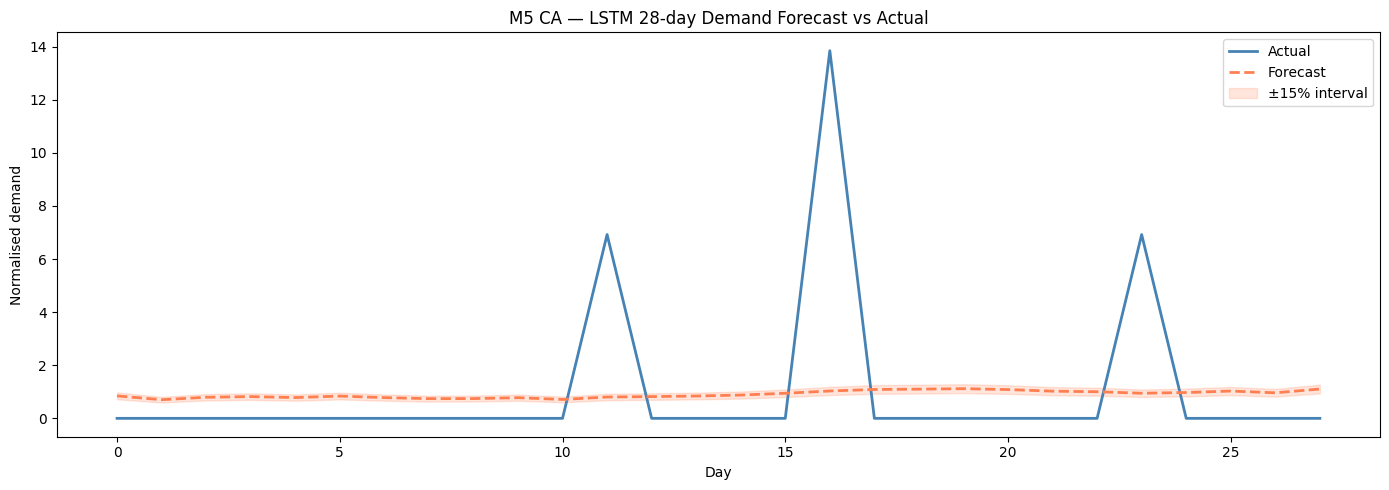

Chart saved to notebooks/m5_forecast_chart.png


In [18]:
model.eval()
with torch.no_grad():
    sample_idx  = 0
    sample_X    = X_val[sample_idx:sample_idx+1]
    sample_y    = y_val[sample_idx].numpy()
    sample_pred = model(sample_X).squeeze().numpy()

plt.figure(figsize=(14, 5))
plt.plot(range(HORIZON), sample_y,    label="Actual",   color="steelblue", linewidth=2)
plt.plot(range(HORIZON), sample_pred, label="Forecast", color="coral",     linewidth=2, linestyle="--")
plt.fill_between(
    range(HORIZON),
    sample_pred * 0.85,
    sample_pred * 1.15,
    alpha=0.2, color="coral", label="±15% interval"
)
plt.title("M5 CA — LSTM 28-day Demand Forecast vs Actual")
plt.xlabel("Day")
plt.ylabel("Normalised demand")
plt.legend()
plt.tight_layout()
plt.savefig("../notebooks/m5_forecast_chart.png", dpi=150)
plt.show()
print("Chart saved to notebooks/m5_forecast_chart.png")